# Comparison of sandpile model in different scenarios and test of SOC

# Sandpile model with single grain dropped at a time at a random site

###### Use "SHIFT + ALT + A" to decomment

In [40]:
# Importing libraries and setting up parameters

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Grid parameters
L = 50
threshold = 4
total_grains = 7000

rng = np.random.default_rng()

# Initialize grid
grid_std = np.zeros((L, L), dtype=int)

In [41]:
# Defining functions for the sandpile model

def add_grain():                 # Adding a grain to a random site     
    i = rng.integers(0, L)
    j = rng.integers(0, L)
    grid[i, j] += 1
    return i, j


def topple(grid, i, j):         # Toppling a site and distribute grains to neighbors
    grid[i, j] -= 4
    neighbors = [(i+1,j),(i-1,j),(i,j+1),(i,j-1)]
    for p, q in neighbors:
        if 0 <= p < L and 0 <= q < L:
            grid[p, q] += 1

def any_unstable(grid):         # Checking if there are any unstable sites in the grid 
    return np.any(grid >= threshold)

def relax_with_footprint(grid):
    avalanche_size = 0
    toppled_sites = set()

    while any_unstable(grid):       # Relaxing the grid until there are no unstable sites
        for i in range(L):
            for j in range(L):
                if grid[i, j] >= threshold:
                    topple(grid, i, j)
                    avalanche_size += 1
                    toppled_sites.add((i, j))

    return avalanche_size, toppled_sites



In [42]:
# Simulation loop

sizes_std = []
areas_std = []
footprints_std = []

for step in range(total_grains):
    i = rng.integers(0, L)
    j = rng.integers(0, L)
    grid_std[i, j] += 1
    
    s, sites = relax_with_footprint(grid_std)
    
    sizes_std.append(s)
    areas_std.append(len(sites))
    footprints_std.append(sites)

print("Standard model complete.")

Standard model complete.


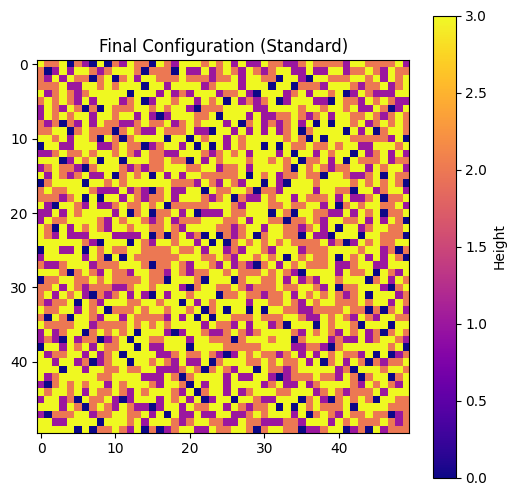

In [51]:
# Plotting final grid state

plt.figure(figsize=(6,6))
plt.imshow(grid_std, cmap='plasma', vmin=0, vmax=3)
plt.colorbar(label="Height")
plt.title("Final Configuration (Standard)")
plt.savefig("final_grid_std.png", dpi=300, bbox_inches="tight")
plt.show()


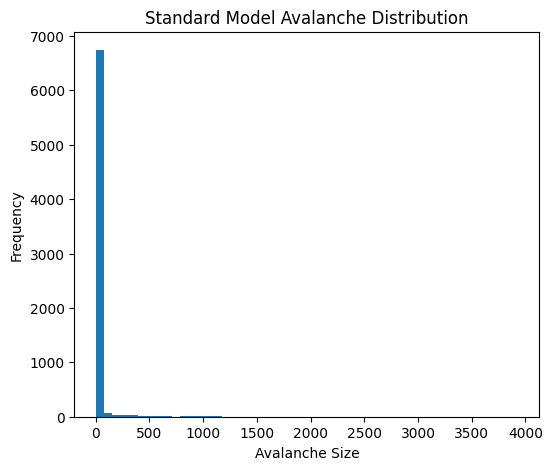

In [44]:
# Plotting avalanche size distribution histogram

plt.figure(figsize=(6,5))
plt.hist(sizes_std, bins=50)
plt.xlabel("Avalanche Size")
plt.ylabel("Frequency")
plt.title("Standard Model Avalanche Distribution")
plt.savefig("hist_sizedist_std.png", dpi=300, bbox_inches="tight")
plt.show()

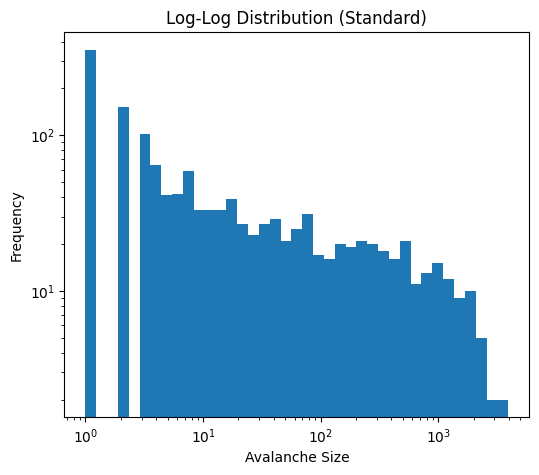

In [45]:
# Log-log plot of avalanche size distribution

plt.figure(figsize=(6,5))
plt.hist(sizes_std, bins=np.logspace(0, np.log10(max(sizes_std)+1), 40))
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Avalanche Size")
plt.ylabel("Frequency")
plt.title("Log-Log Distribution (Standard)")
plt.savefig("log_hist_std.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
""" # Storing the evolution of the grid as a video

fig, ax = plt.subplots(figsize=(6, 6))
im = plt.imshow(frames[0], cmap='plasma', vmin=0, vmax=3)

def update(frame):
    im.set_array(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=frames, blit=True)

ani.save("sandpile_evolution.mp4", writer="ffmpeg", fps=30)

plt.close()
print("Video saved as sandpile_evolution.mp4")

from IPython.display import Video   # To display the video in the notebook
Video("sandpile_evolution.mp4") """

' # Storing the evolution of the grid as a video\n\nfig, ax = plt.subplots(figsize=(6, 6))\nim = plt.imshow(frames[0], cmap=\'plasma\', vmin=0, vmax=3)\n\ndef update(frame):\n    im.set_array(frame)\n    return [im]\n\nani = animation.FuncAnimation(fig, update, frames=frames, blit=True)\n\nani.save("sandpile_evolution.mp4", writer="ffmpeg", fps=30)\n\nplt.close()\nprint("Video saved as sandpile_evolution.mp4")\n\nfrom IPython.display import Video   # To display the video in the notebook\nVideo("sandpile_evolution.mp4") '

### Avalanche footprint and fractal geometry visualization

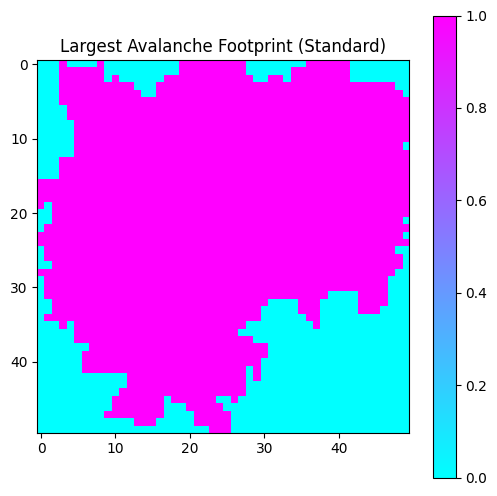

In [47]:
# Identifying and plotting the largest avalanche footprint

max_index_std = np.argmax(sizes_std)
largest_sites_std = footprints_std[max_index_std]

footprint_grid_std = np.zeros((L,L))
for i,j in largest_sites_std:
    footprint_grid_std[i,j] = 1

plt.figure(figsize=(6,6))
plt.imshow(footprint_grid_std, cmap="cool")
plt.title("Largest Avalanche Footprint (Standard)")
plt.colorbar()
plt.savefig("largest_footprint_std.png", dpi=300, bbox_inches="tight")
plt.show()

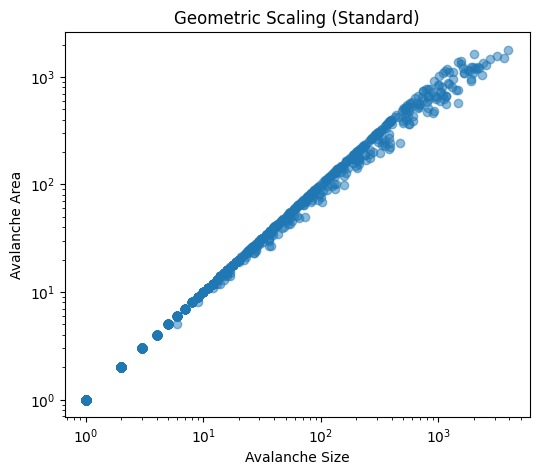

In [48]:
# Log-log plot of avalanche size vs area 

plt.figure(figsize=(6,5))
plt.scatter(sizes_std, areas_std, alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Avalanche Size")
plt.ylabel("Avalanche Area")
plt.title("Geometric Scaling (Standard)")
plt.savefig("log_geo_scale_std.png", dpi=300, bbox_inches="tight")
plt.show()


## Sandpile model with variation in drive, where we increase the number of grains added per step after every 50 steps

In [49]:
# Setting up parameters and initializing variables for the simulation

grid_var = np.zeros((L, L), dtype=int)
sizes_var = []
areas_var = []
footprints_var = []

In [52]:
# Simulation loop for the variant model with increasing grain addition 

for step in range(total_grains):
    
    grains_to_add = step // 100 + 1
    
    i = rng.integers(0, L)
    j = rng.integers(0, L)
    grid_var[i, j] += grains_to_add
    
    s, sites = relax_with_footprint(grid_var)
    
    sizes_var.append(s)
    areas_var.append(len(sites))
    footprints_var.append(sites)

print("Variant model complete.")


Variant model complete.


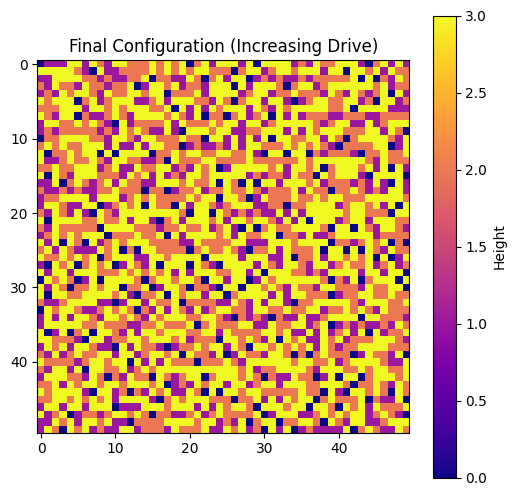

In [53]:
# Plotting final grid state for the variant model

plt.figure(figsize=(6,6))
plt.imshow(grid_var, cmap='plasma', vmin=0, vmax=3)
plt.colorbar(label="Height")
plt.title("Final Configuration (Increasing Drive)")
plt.savefig("final_grid_var.png", dpi=300, bbox_inches="tight")
plt.show()

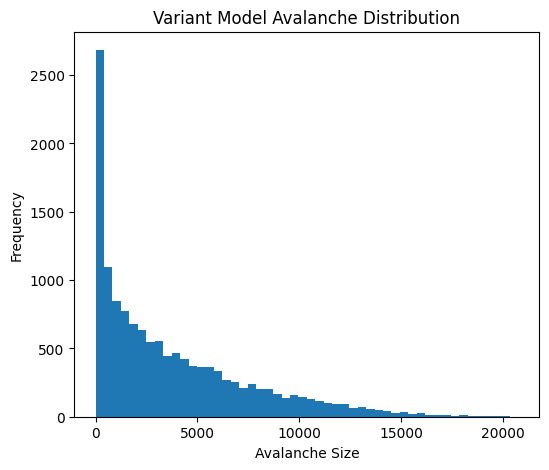

In [54]:
# Plotting avalanche size distribution histogram for the variant model

plt.figure(figsize=(6,5))
plt.hist(sizes_var, bins=50)
plt.xlabel("Avalanche Size")
plt.ylabel("Frequency")
plt.title("Variant Model Avalanche Distribution")
plt.savefig("hist_sizedist_var.png", dpi=300, bbox_inches="tight")
plt.show()

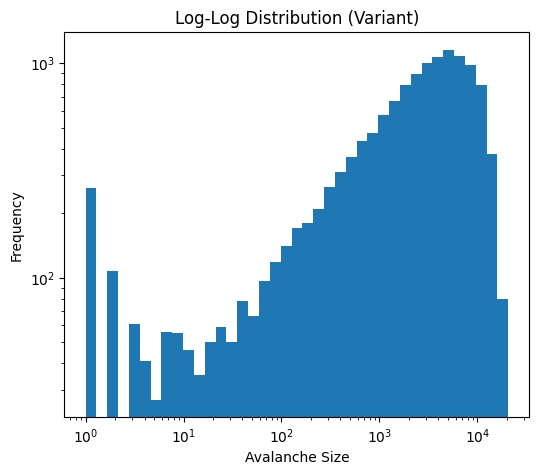

In [55]:
# Log-log plot of avalanche size distribution for the variant model 

plt.figure(figsize=(6,5))
plt.hist(sizes_var, bins=np.logspace(0, np.log10(max(sizes_var)+1), 40))
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Avalanche Size")
plt.ylabel("Frequency")
plt.title("Log-Log Distribution (Variant)")
plt.savefig("log_hist_var.png", dpi=300, bbox_inches="tight")
plt.show()

### Avalanche footprint and fractal geometry visualization for variant model

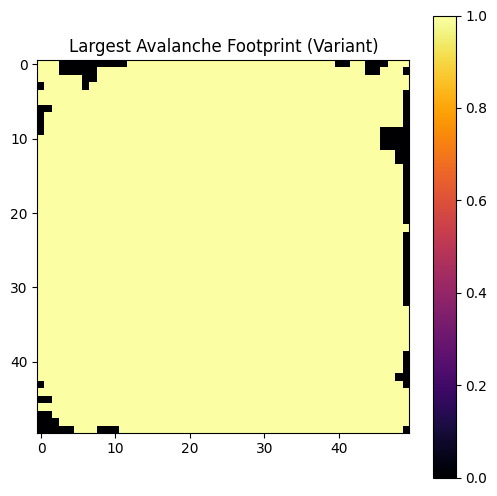

In [56]:
# Identifying and plotting the largest avalanche footprint for the variant model

max_index_var = np.argmax(sizes_var)
largest_sites_var = footprints_var[max_index_var]

footprint_grid_var = np.zeros((L,L))
for i,j in largest_sites_var:
    footprint_grid_var[i,j] = 1

plt.figure(figsize=(6,6))
plt.imshow(footprint_grid_var, cmap="inferno")
plt.title("Largest Avalanche Footprint (Variant)")
plt.colorbar()
plt.savefig("largest_footprint_var.png", dpi=300, bbox_inches="tight")
plt.show()

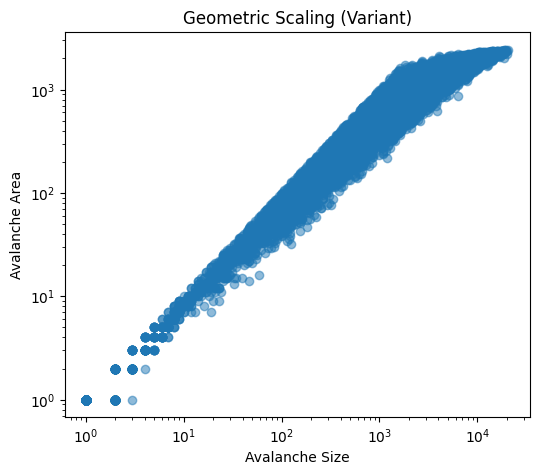

In [57]:
# Log-log plot of avalanche size vs area for the variant model

plt.figure(figsize=(6,5))
plt.scatter(sizes_var, areas_var, alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Avalanche Size")
plt.ylabel("Avalanche Area")
plt.title("Geometric Scaling (Variant)")
plt.savefig("log_geo_scale_var.png", dpi=300, bbox_inches="tight")
plt.show()


## Comparison plots

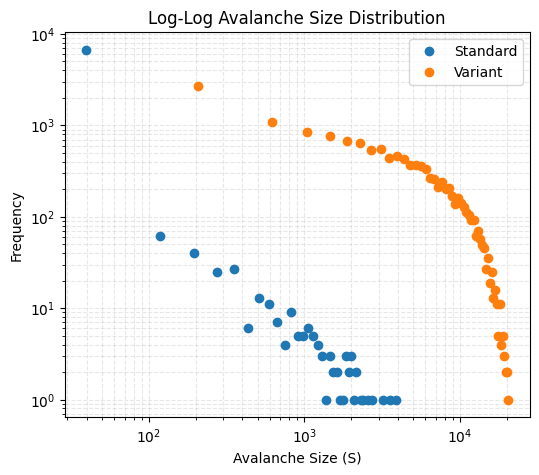

In [58]:
# Comparative log-log plot of avalanche size distributions for both models

def loglog_distribution(data, label):
    counts, bins = np.histogram(data, bins=50)
    
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    mask = counts > 0
    
    plt.loglog(bin_centers[mask], counts[mask], 'o', label=label)

plt.figure(figsize=(6,5))

loglog_distribution(sizes_std, "Standard")
loglog_distribution(sizes_var, "Variant")

plt.xlabel("Avalanche Size (S)")
plt.ylabel("Frequency")
plt.title("Log-Log Avalanche Size Distribution")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.savefig("loglog_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


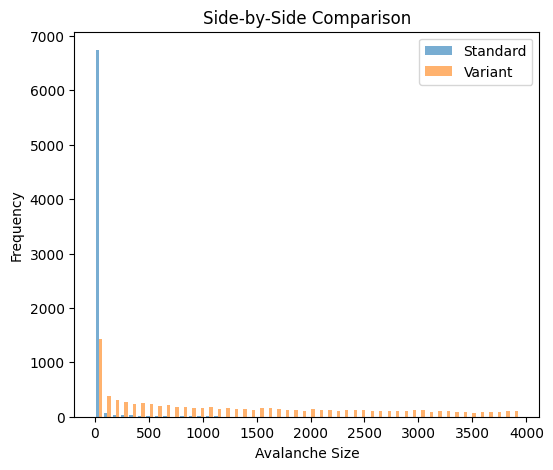

In [59]:
# Side-by-side bar plot of avalanche size distributions for both models using the same bins

counts_std, bins = np.histogram(sizes_std, bins=50)
counts_var, _ = np.histogram(sizes_var, bins=bins)

bin_centers = 0.5 * (bins[1:] + bins[:-1])
width = (bins[1] - bins[0]) * 0.4

plt.figure(figsize=(6,5))

plt.bar(bin_centers - width/2, counts_std, width=width, alpha=0.6, label="Standard")
plt.bar(bin_centers + width/2, counts_var, width=width, alpha=0.6, label="Variant")

plt.xlabel("Avalanche Size")
plt.ylabel("Frequency")
plt.legend()
plt.title("Side-by-Side Comparison")

plt.savefig("hist_side_by_side.png", dpi=300, bbox_inches="tight")
plt.show()


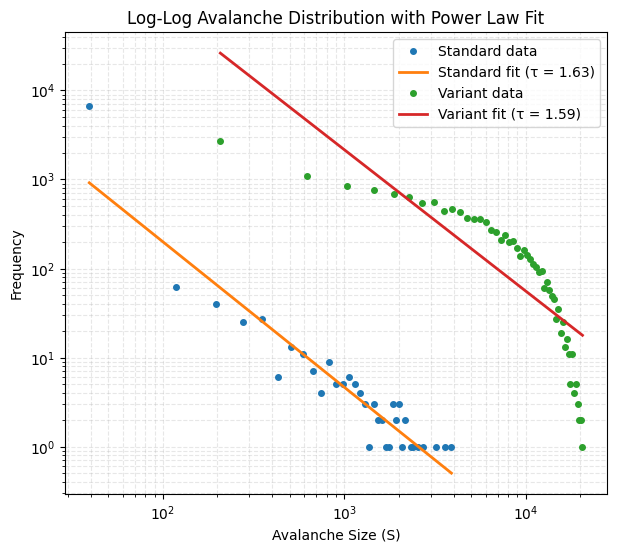

Estimated exponent (Standard): 1.6340967567579736
Estimated exponent (Variant): 1.5880731391745908


In [60]:
# Function to perform power law fit on the avalanche size distribution and plot the results

def power_law_fit(data, label):
    counts, bins = np.histogram(data, bins=50)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    mask = (counts > 0) & (bin_centers > 0)
    x = bin_centers[mask]
    y = counts[mask]

    log_x = np.log10(x)
    log_y = np.log10(y)

    slope, intercept = np.polyfit(log_x, log_y, 1)

    fit_y = 10**intercept * x**slope

    plt.loglog(x, y, 'o', markersize=4, label=f"{label} data")

    plt.loglog(x, fit_y, '-', linewidth=2,
               label=f"{label} fit (τ = {-slope:.2f})")

    return slope


plt.figure(figsize=(7,6))

slope_std = power_law_fit(sizes_std, "Standard")
slope_var = power_law_fit(sizes_var, "Variant")

plt.xlabel("Avalanche Size (S)")
plt.ylabel("Frequency")
plt.title("Log-Log Avalanche Distribution with Power Law Fit")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.savefig("loglog_powerlaw_fit.png", dpi=300, bbox_inches="tight")
plt.show()

print("Estimated exponent (Standard):", -slope_std)
print("Estimated exponent (Variant):", -slope_var)


### Toppling frequency heatmap

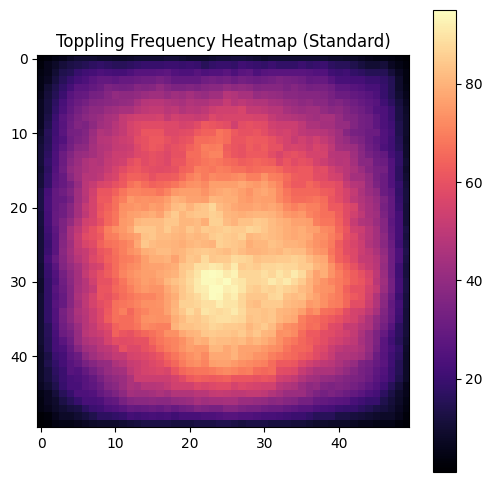

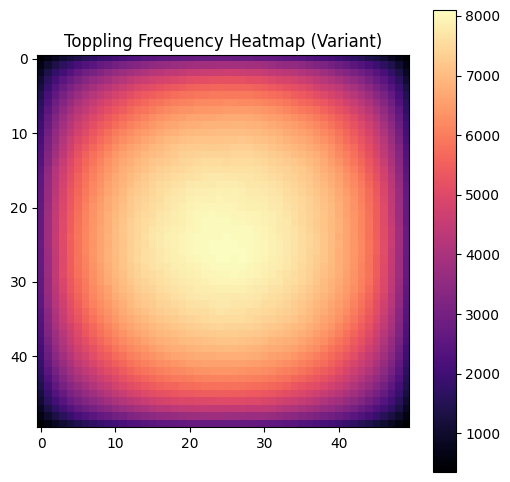

In [61]:
# Heatmap of toppling frequency for both models

def topple_heatmap(footprints):
    heat = np.zeros((L,L))
    for sites in footprints:
        for i,j in sites:
            heat[i,j] += 1
    return heat

heat_std = topple_heatmap(footprints_std)
heat_var = topple_heatmap(footprints_var)

plt.figure(figsize=(6,6))
plt.imshow(heat_std, cmap="magma")
plt.title("Toppling Frequency Heatmap (Standard)")
plt.colorbar()
plt.savefig("toppling_freq_std.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(heat_var, cmap="magma")
plt.title("Toppling Frequency Heatmap (Variant)")
plt.colorbar()
plt.savefig("toppling_freq_var.png", dpi=300, bbox_inches="tight")
plt.show()
